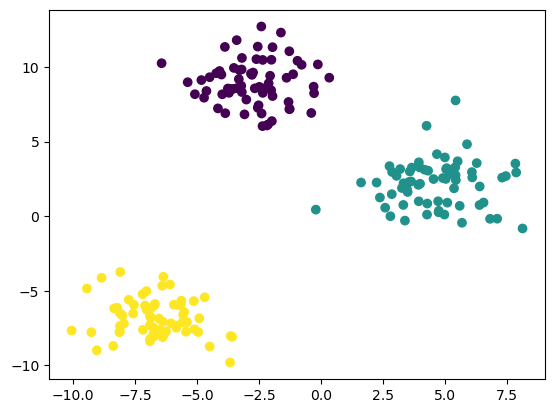

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# 데이터 생성
X,y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)
# 시각화
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


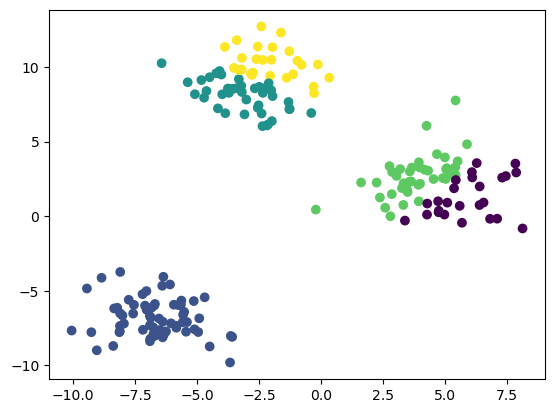

In [7]:
from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=5)
y_predict =kmeans.fit_predict(X)
# 시각화
plt.scatter(X[:,0],X[:,1],c=y_predict)
plt.show()

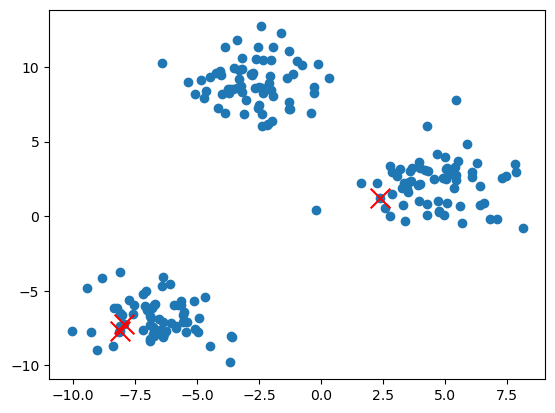

In [21]:
import numpy as np
# step 1 - 초기 중심 : 처음 중심을 랜덤으로 선택
k = 3
np.random.seed(42)
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]
plt.scatter(X[:,0], X[:,1])
plt.scatter(centroids[:,0], centroids[:,1],c='red', marker='x',s=200)
plt.show()

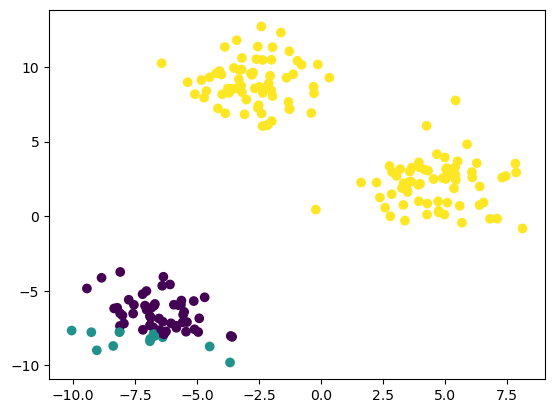

In [53]:
# step2 각 점을 가장 가까운 중심에 할당
# 거리계산 -> 가장 가까운 중심 선택
def assign_cluster(X, centroids):
    distance = np.linalg.norm(X[:,np.newaxis] - centroids, axis=2)
    return np.argmin(distance,axis=1)
labels = assign_cluster(X,centroids)
# 각 점이 0 1 2중 하나로 배정됨
plt.scatter(X[:,0], X[:,1],c = labels)
plt.show()

In [ ]:
print(X[:,np.newaxis].shape, X.shape, centroids.shape)
# 점 200개 x centroid 3개 x 좌표2
# 첫번째 점  [1,2]
# centroid : [3,4] [5,6] [7,8]
# [1-3, 2-4] [1-5, 2-6], [1-7, 2-8]
# 모든 centroid와의 좌표계산
# 유클리드거리 (np.linalg.norm)   (x차이**2 + y차이**2)(1/2) axis=2 좌표방향
# np.argmin(distance,axis=1) 가장 가까운 centroid 선택


(200, 1, 2) (200, 2) (3, 2)


In [54]:
# step3 중심이동
# 각 그룹의 평균을 계산  --> 새로운 중심
def update_centroid(X,labels,k):
    return np.array(
        [ X[labels==i].mean(axis=0) for i in range(k) ]
    )

centroids = update_centroid(X,labels,k)   
centroids
    

array([[-6.52538496, -6.47920158],
       [-7.30160668, -8.29627639],
       [ 0.94735044,  5.54722254]])